In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [5]:
df = pd.read_csv('../data/Churn Modeling.csv')

# 1. Load Data

In [6]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1467,1468,15681843,Barbour,624,Germany,Female,35,0,180303.24,2,1,0,163587.90,0
1002,1003,15633897,Owen,725,Germany,Male,39,1,50880.98,2,1,1,184023.54,0
1551,1552,15749177,Maslow,730,Spain,Female,52,7,0.00,2,0,1,122398.84,0
2857,2858,15769829,Cheng,534,Spain,Male,51,3,0.00,2,0,1,20856.31,0
90,91,15757535,Heap,647,Spain,Female,44,5,0.00,3,1,1,174205.22,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


 # 2. Understand Data

In [10]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

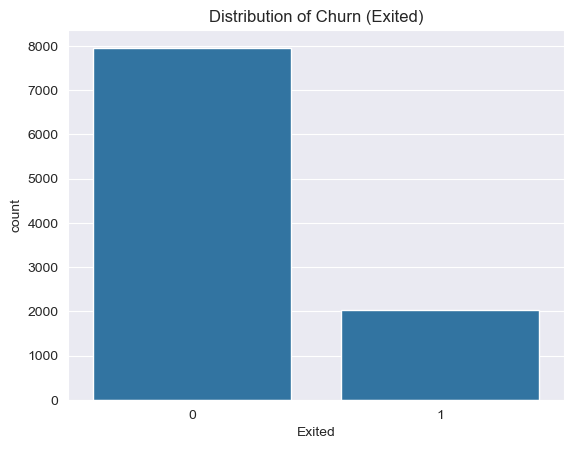

In [11]:
sns.countplot(x='Exited', data=df)
plt.title('Distribution of Churn (Exited)')
plt.show()

# 3. Data Clean-Up


In [12]:
# Xóa cột không cần thiết
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [13]:
# Mã hóa biến phân loại
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [14]:
# Kiểm tra cân bằng dữ liệu
churn_rate = df['Exited'].value_counts(normalize=True)
print(f"Churn Rate: {churn_rate[1]:.2%}")

Churn Rate: 20.37%


In [15]:
# Xử lý mất cân bằng dữ liệu bằng SMOTE
X = df.drop('Exited', axis=1)
y = df['Exited']
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 4. Exploratory Data Analysis (EDA)

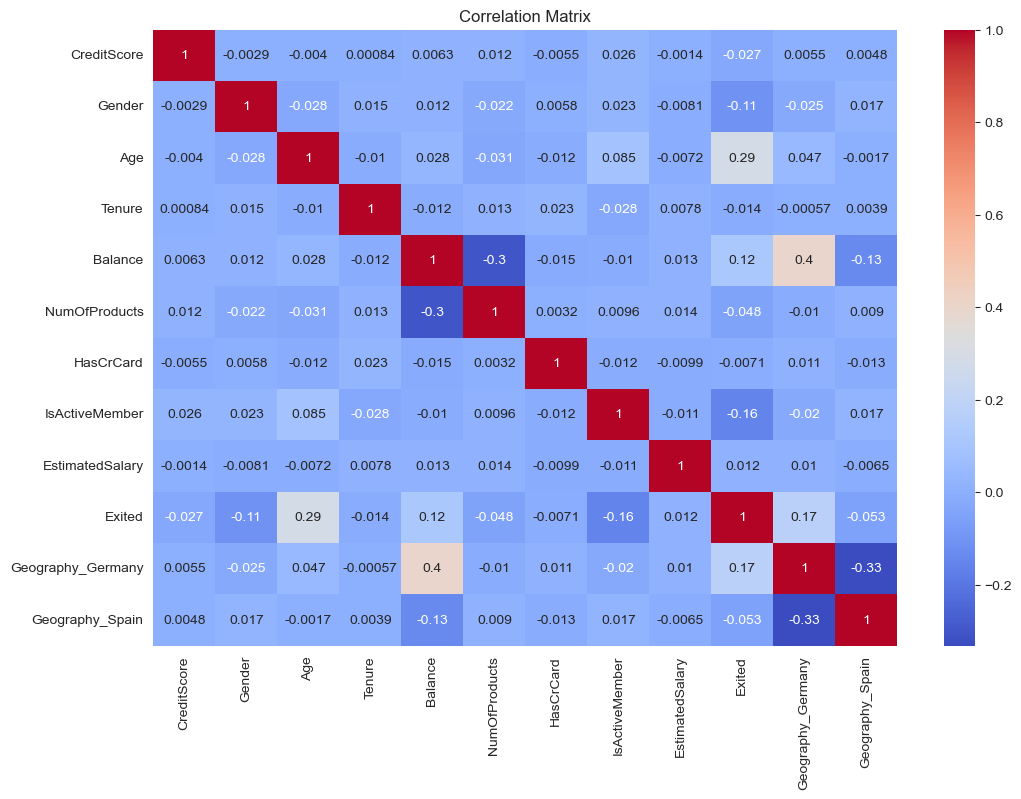

In [16]:
# Phân tích tương quan
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

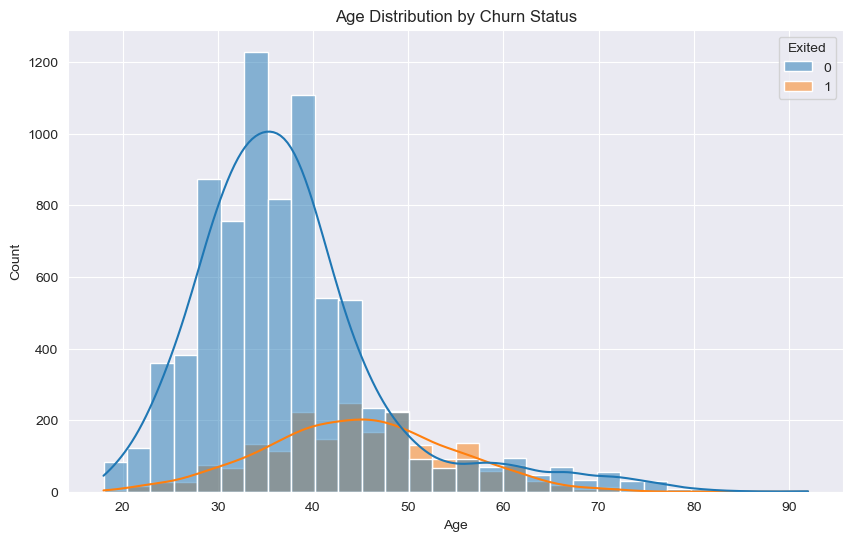

In [17]:
# Phân bố tuổi
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Exited', kde=True, bins=30)
plt.title('Age Distribution by Churn Status')
plt.show()

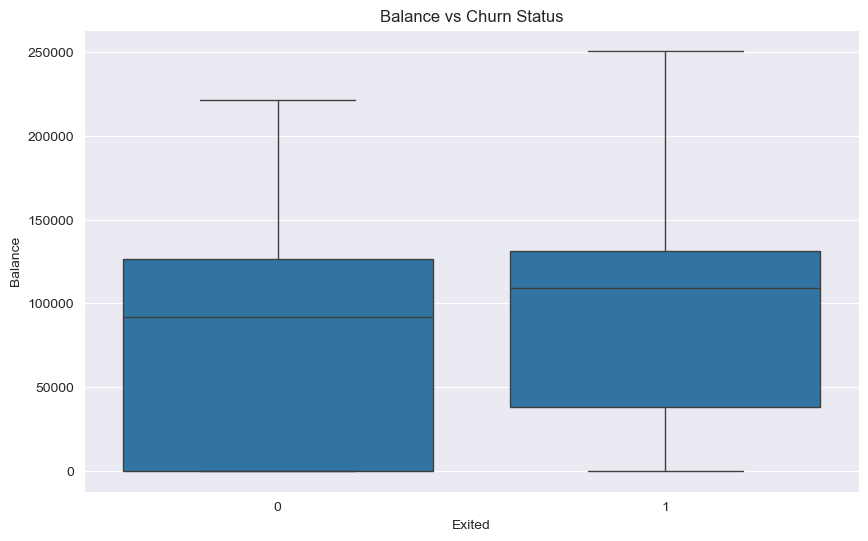

In [18]:
# Phân tích Balance
plt.figure(figsize=(10,6))
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title('Balance vs Churn Status')
plt.show()

# 5. Model Building

In [19]:
# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

In [20]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot confusion matrix
    plt.figure(figsize=(8,6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()

Logistic Regression Performance:
Accuracy: 0.7850
ROC AUC: 0.8644

Confusion Matrix:
[[1285  348]
 [ 337 1216]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      1633
           1       0.78      0.78      0.78      1553

    accuracy                           0.78      3186
   macro avg       0.78      0.78      0.78      3186
weighted avg       0.79      0.78      0.79      3186



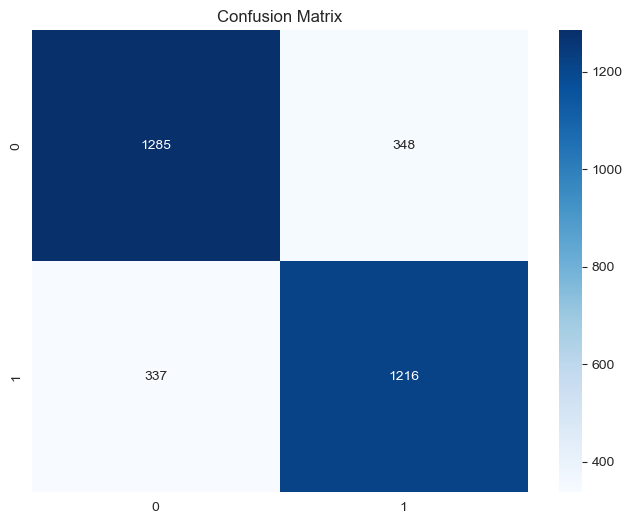

In [22]:
# Mô hình Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
print("Logistic Regression Performance:")
evaluate_model(lr, X_test, y_test)


Random Forest Performance:
Accuracy: 0.8723
ROC AUC: 0.9420

Confusion Matrix:
[[1427  206]
 [ 201 1352]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      1633
           1       0.87      0.87      0.87      1553

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186



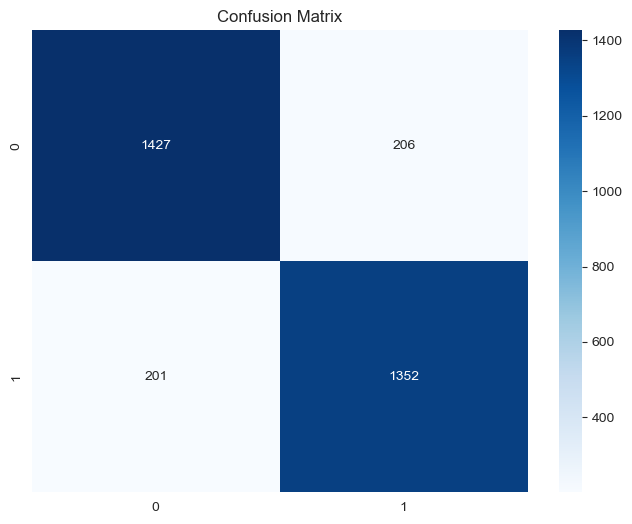

In [23]:
# Mô hình Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("\nRandom Forest Performance:")
evaluate_model(rf, X_test, y_test)

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [17:00:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Performance:
Accuracy: 0.8719
ROC AUC: 0.9438

Confusion Matrix:
[[1419  214]
 [ 194 1359]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1633
           1       0.86      0.88      0.87      1553

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186



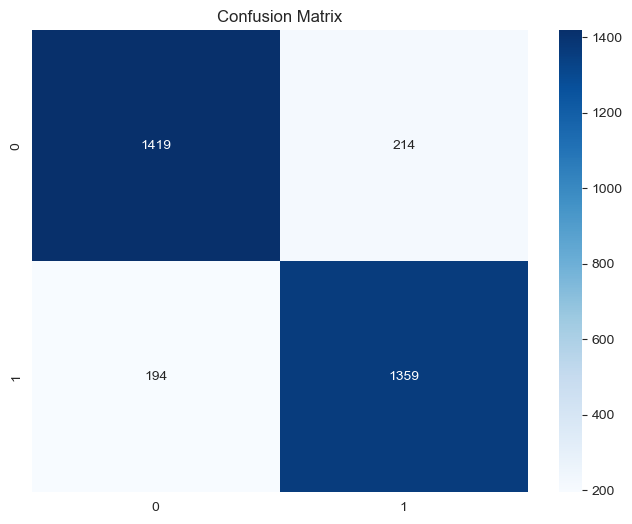

In [24]:
# Mô hình XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
print("\nXGBoost Performance:")
evaluate_model(xgb, X_test, y_test)

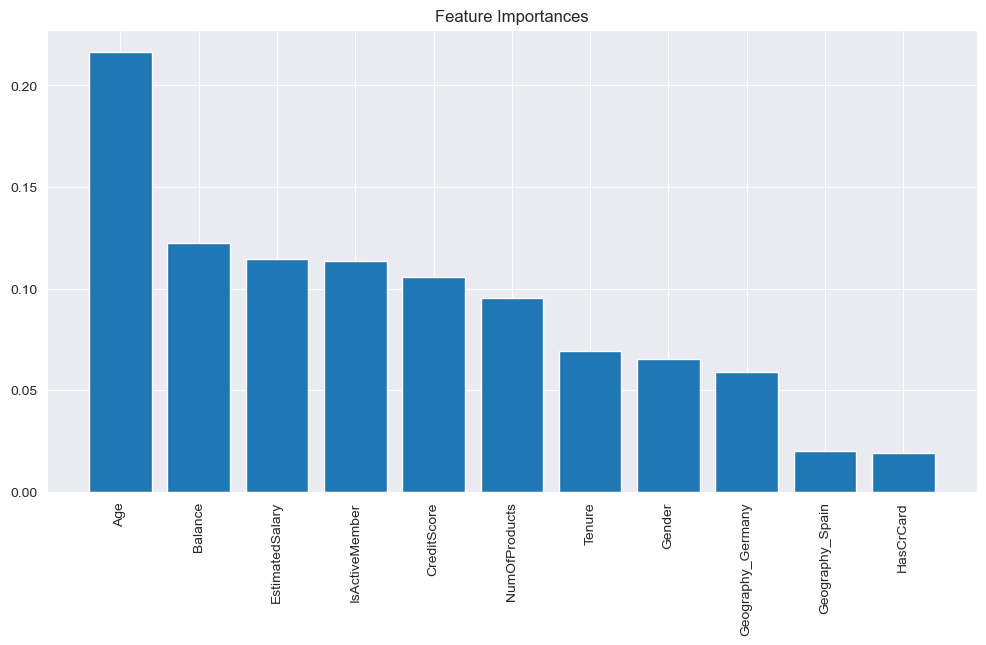

In [25]:
# Hiển thị feature importance
features = X.columns
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title('Feature Importances')
plt.bar(range(len(indices)), importances[indices], align='center')
plt.xticks(range(len(indices)), [features[i] for i in indices], rotation=90)
plt.show()

In [26]:
import joblib
joblib.dump(rf, 'best_churn_model.pkl')  # Lưu mô hình Random Forest

# Để sử dụng sau này:
# loaded_model = joblib.load('best_churn_model.pkl')
# predictions = loaded_model.predict(new_data)

['best_churn_model.pkl']